In [1]:
!pip install rdkit chembl_webresource_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import DataStructs, Descriptors, Draw
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from chembl_webresource_client.new_client import new_client

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [3]:
# ChEMBL se data lao
activity = new_client.activity

activities = activity.filter(
    target_chembl_id='CHEMBL4295754',
    standard_type='IC50'
).only(['molecule_chembl_id', 'canonical_smiles',
        'standard_value', 'standard_units'])

df = pd.DataFrame(list(activities))
df['IC50_nM'] = pd.to_numeric(df['standard_value'], errors='coerce')

print(f"✅ Downloaded {len(df)} GPX4 inhibitors")
df.head()

✅ Downloaded 11 GPX4 inhibitors


,canonical_smiles,molecule_chembl_id,standard_units,standard_value,units,value,IC50_nM
0,COc1cc(N(C(=O)CCl)c2ccc3c(c2)OCCO3)cc(OC)c1F,CHEMBL5422297,nM,120.0,uM,0.12,120.0
1,COc1cc(N(C(=O)CBr)c2ccc3c(c2)OCCO3)cc(OC)c1F,CHEMBL5415644,nM,130.0,uM,0.13,130.0
2,COC(=O)c1ccc([C@H]2c3[nH]c4ccccc4c3C[C@H](C(=O...,CHEMBL4747331,nM,8420.0,uM,8.42,8420.0
3,COc1ccc(N(C(=O)CCl)C(C(=O)NCCc2ccccc2)c2cccs2)...,CHEMBL1499544,nM,4850.0,uM,4.85,4850.0
4,COc1ccc2c(c1)NC(=O)/C2=C1\Nc2ccccc2\C1=N/OCCCN...,CHEMBL5570241,nM,542.5,nM,542.5,542.5


In [4]:
mfpgen = GetMorganGenerator(radius=2)

# UDS1b
uds1b_mol = Chem.MolFromSmiles('C1=CC=CC=C1C(C[Se]C(C2=CC=CC=C2)=O)=O')
uds1b_fp = mfpgen.GetFingerprint(uds1b_mol)

# Similarities
sims = []
for smiles in df['canonical_smiles']:
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        fp = mfpgen.GetFingerprint(mol)
        sims.append(DataStructs.TanimotoSimilarity(uds1b_fp, fp) * 100)
    else:
        sims.append(0)

df['Similarity_%'] = sims
df_sorted = df.sort_values('Similarity_%', ascending=False).reset_index(drop=True)
df_sorted[['molecule_chembl_id', 'IC50_nM', 'Similarity_%']]

,molecule_chembl_id,IC50_nM,Similarity_%
0,CHEMBL1499544,4850.0,15.714286
1,CHEMBL1499544,2700.0,15.714286
2,CHEMBL4747331,8420.0,14.705882
3,CHEMBL5596393,26700.0,14.084507
4,CHEMBL5647419,6480.0,13.888889
5,CHEMBL5415644,130.0,11.666667
6,CHEMBL5422297,120.0,11.666667
7,CHEMBL5272075,86600.0,11.111111
8,CHEMBL1232461,10000.0,9.333333
9,CHEMBL5597052,10000.0,9.016393


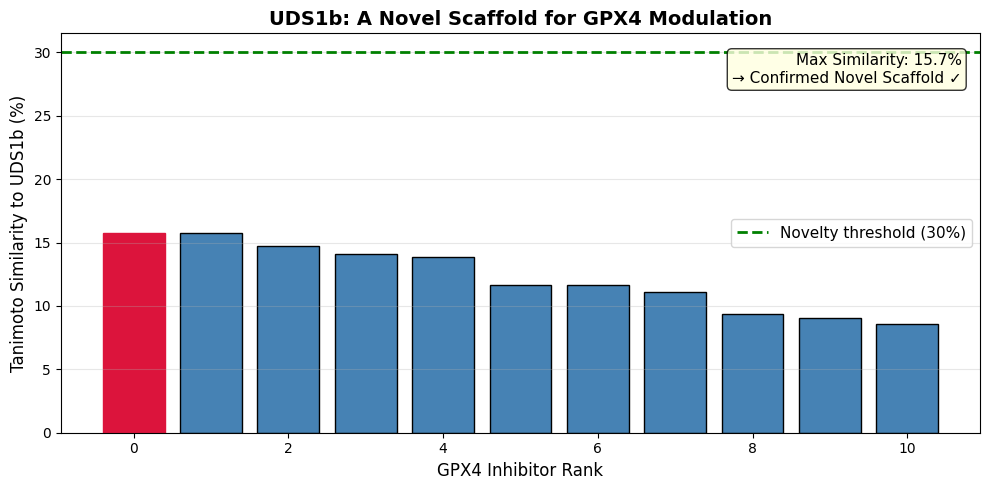


✅ Publication-quality figure saved!


In [5]:
import matplotlib.pyplot as plt

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

# Bar plot
bars = ax.bar(range(len(df_sorted)),
              df_sorted['Similarity_%'],
              color='steelblue', edgecolor='black')

# Highest ko red
bars[0].set_color('crimson')

# Threshold line
ax.axhline(y=30, color='green', linestyle='--',
           linewidth=2, label='Novelty threshold (30%)')

# Labels
ax.set_xlabel('GPX4 Inhibitor Rank', fontsize=12)
ax.set_ylabel('Tanimoto Similarity to UDS1b (%)', fontsize=12)
ax.set_title('UDS1b: A Novel Scaffold for GPX4 Modulation',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Stats annotation
max_sim = df_sorted['Similarity_%'].max()
ax.text(0.98, 0.95, f'Max Similarity: {max_sim:.1f}%\n→ Confirmed Novel Scaffold ✓',
        transform=ax.transAxes, fontsize=11,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('uds1b_novelty_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Publication-quality figure saved!")

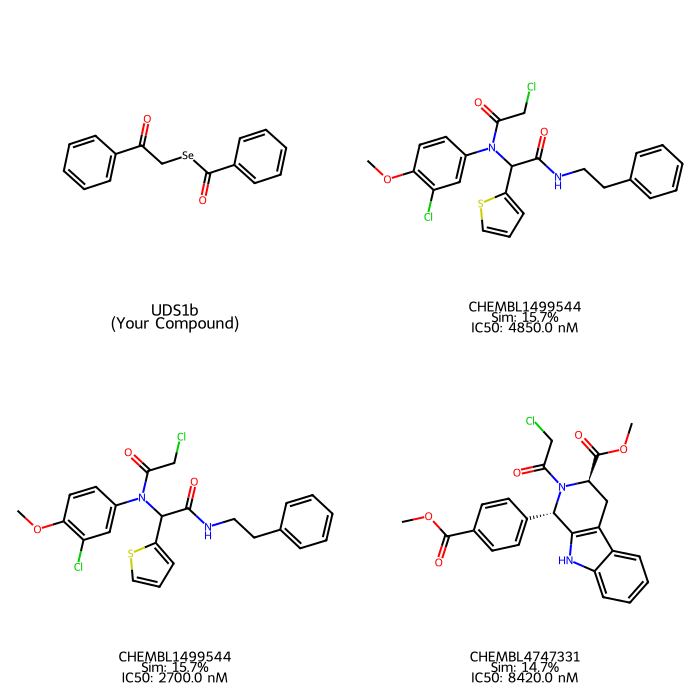

In [6]:
from rdkit.Chem import Draw

# Top 3 most similar + UDS1b ki structures
top_3 = df_sorted.head(3)

# Molecules banao
mols = [Chem.MolFromSmiles('C1=CC=CC=C1C(C[Se]C(C2=CC=CC=C2)=O)=O')]
labels = ['UDS1b\n(Your Compound)']

for _, row in top_3.iterrows():
    mol = Chem.MolFromSmiles(row['canonical_smiles'])
    if mol:
        mols.append(mol)
        labels.append(f"{row['molecule_chembl_id']}\nSim: {row['Similarity_%']:.1f}%\nIC50: {row['IC50_nM']} nM")

# Grid mein dikhao
img = Draw.MolsToGridImage(
    mols,
    molsPerRow=2,
    subImgSize=(350, 350),
    legends=labels
)
img